# 5x5 Activity PRC -- all datasets

Aggregated precision-recall / ROC results from 5x5 activity simulations
(5 ground-truth draws x 5 simulation replicates, 70% inactive).

Uses `de_novo_simulation` built-in methods for curve plotting and metrics.

**Canonical models:**
- Shendure: obs NB
- Cohen: obsingle NB
- Seelig: CM NB

In [1]:
import sys
sys.path.insert(0, "/nfs/roberts/project/pi_skr2/mcn26/tabula-rasa")
import scMPRAforge as scm
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SIM_ROOT = Path("/nfs/roberts/project/pi_skr2/shared/tabula_data_new/simulated")
N_GT_DRAWS = 5
HYPOTHESIS_SET = "hs_all_ct"

DATASETS = {
    "Shendure (obs NB)": "shendure_5x5_activity",
    "Cohen (obsingle NB)": "cohen_5x5_activity",
    "Seelig (CM NB)": "seelig_5x5_activity",
}

I0000 00:00:1775583395.770176   77033 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1775583397.858953   77033 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# de_novo_simulation.__init__ re-hydrates saved futures via client.submit,
# so we need a real (but minimal) Dask client even for read-only summary work.
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=1, threads_per_worker=1, memory_limit="4GB")
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")

# Load all simulation objects
sims = {}  # {dataset_label: [sim_gt0, sim_gt1, ...]}
for label, prefix in DATASETS.items():
    gt_sims = []
    for gt_idx in range(N_GT_DRAWS):
        name = f"{prefix}_gt{gt_idx}"
        try:
            sim = scm.de_novo_simulation(location=SIM_ROOT, name=name, client=client)
            gt_sims.append(sim)
        except Exception as e:
            print(f"Failed to load {name}: {e}")
    if gt_sims:
        sims[label] = gt_sims
        print(f"{label}: loaded {len(gt_sims)}/{N_GT_DRAWS} GT draws")
    else:
        print(f"{label}: no data available")

scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt0', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt1', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt2', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt3', loading.


scMPRAforge: INFO: 'state.parquet' found for 'shendure_5x5_activity_gt4', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt1', loading.


scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt2', loading.


scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt3', loading.


scMPRAforge: INFO: 'state.parquet' found for 'seelig_5x5_activity_gt4', loading.


Cohen (obsingle NB): loaded 5/5 GT draws
Seelig (CM NB): loaded 5/5 GT draws


## Summary table: AUROC/AUPRC across all GT draws and replicates

In [3]:
all_summaries = {}
for label, gt_sims in sims.items():
    parts = []
    for gt_idx, sim in enumerate(gt_sims):
        try:
            summary = sim._all_classifier_summary(HYPOTHESIS_SET)
            summary["gt_draw"] = gt_idx
            parts.append(summary)
        except Exception as e:
            print(f"{label} GT {gt_idx}: {e}")
    if parts:
        all_summaries[label] = pd.concat(parts, ignore_index=True)

# Display aggregate table
rows = []
for label, df in all_summaries.items():
    for test in sorted(df["test"].unique()):
        sub = df[df["test"] == test]
        rows.append({
            "Dataset": label,
            "Test": test,
            "AUROC": f"{sub['auroc'].mean():.3f} +/- {sub['auroc'].std():.3f}",
            "AUPRC": f"{sub['auprc'].mean():.3f} +/- {sub['auprc'].std():.3f}",
            "n": len(sub),
        })
pd.DataFrame(rows)

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


...

scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 2686 or 100.0% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 100.0% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


Seelig (CM NB) GT 4: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


,Dataset,Test,AUROC,AUPRC,n
0,Shendure (obs NB),mwu,0.922 +/- 0.012,0.914 +/- 0.013,25
1,Shendure (obs NB),wald_auto,0.923 +/- 0.012,0.914 +/- 0.012,25
2,Cohen (obsingle NB),mwu,0.880 +/- 0.028,0.863 +/- 0.028,25
3,Cohen (obsingle NB),wald_auto,0.751 +/- 0.133,0.649 +/- 0.221,25
4,Seelig (CM NB),mwu,0.670 +/- 0.022,0.527 +/- 0.030,10
5,Seelig (CM NB),wald_auto,0.628 +/- 0.035,0.439 +/- 0.113,10


## Per-GT-draw breakdown

In [4]:
for label, df in all_summaries.items():
    print(f"\n=== {label} ===")
    for test in sorted(df["test"].unique()):
        sub = df[df["test"] == test]
        gt_means = sub.groupby("gt_draw")["auroc"].mean()
        print(f"  {test}:")
        for gt, val in gt_means.items():
            within_std = sub[sub["gt_draw"] == gt]["auroc"].std()
            print(f"    GT {gt}: AUROC={val:.3f} +/- {within_std:.3f}")
        print(f"    between-draw spread: {gt_means.max() - gt_means.min():.3f}")


=== Shendure (obs NB) ===
  mwu:
    GT 0: AUROC=0.925 +/- 0.015
    GT 1: AUROC=0.927 +/- 0.004
    GT 2: AUROC=0.925 +/- 0.012
    GT 3: AUROC=0.915 +/- 0.014
    GT 4: AUROC=0.920 +/- 0.008
    between-draw spread: 0.013
  wald_auto:
    GT 0: AUROC=0.927 +/- 0.017
    GT 1: AUROC=0.925 +/- 0.006
    GT 2: AUROC=0.929 +/- 0.005
    GT 3: AUROC=0.915 +/- 0.014
    GT 4: AUROC=0.918 +/- 0.009
    between-draw spread: 0.014

=== Cohen (obsingle NB) ===
  mwu:
    GT 0: AUROC=0.895 +/- 0.025
    GT 1: AUROC=0.871 +/- 0.023
    GT 2: AUROC=0.874 +/- 0.015
    GT 3: AUROC=0.872 +/- 0.045
    GT 4: AUROC=0.888 +/- 0.026
    between-draw spread: 0.024
  wald_auto:
    GT 0: AUROC=0.829 +/- 0.068
    GT 1: AUROC=0.736 +/- 0.098
    GT 2: AUROC=0.777 +/- 0.144
    GT 3: AUROC=0.752 +/- 0.190
    GT 4: AUROC=0.661 +/- 0.130
    between-draw spread: 0.168

=== Seelig (CM NB) ===
  mwu:
    GT 2: AUROC=0.661 +/- 0.020
    GT 3: AUROC=0.679 +/- 0.023
    between-draw spread: 0.018
  wald_auto:
 

## Median-replicate PRC curves

For each GT draw, plot the PRC curve of the replicate closest to the median
AUPRC. Shows the actual precision-recall tradeoff, not just summary stats.

`median_performance_curve` creates standalone figures, so we call it inline.

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.



Shendure (obs NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 565 / 2060 (27.4272%)
Called positive: 542 / 2044 (26.5166%)


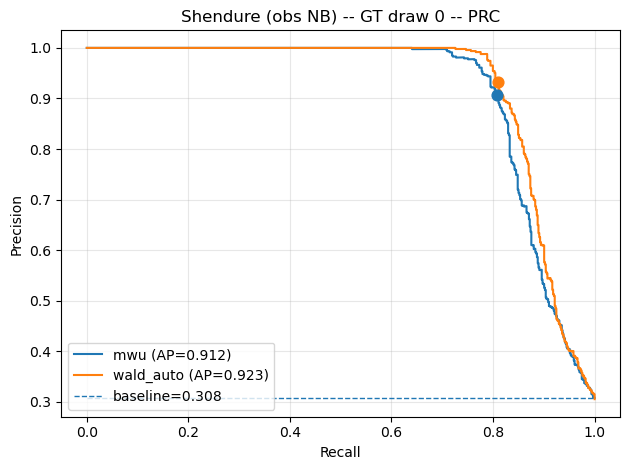

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 574 / 2060 (27.8641%)
Called positive: 590 / 2046 (28.8368%)


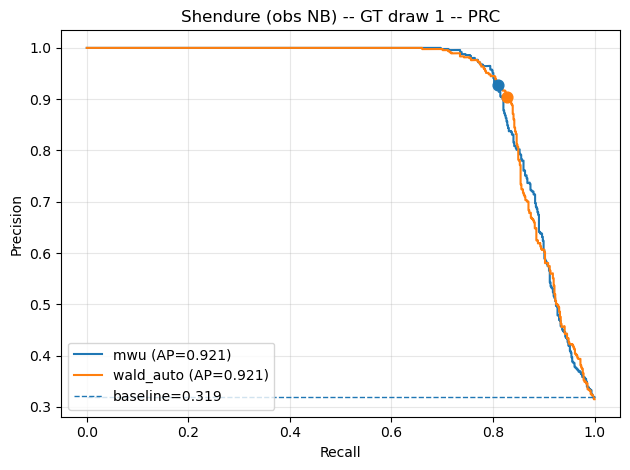

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


Called positive: 609 / 2060 (29.5631%)
Called positive: 577 / 2045 (28.2152%)


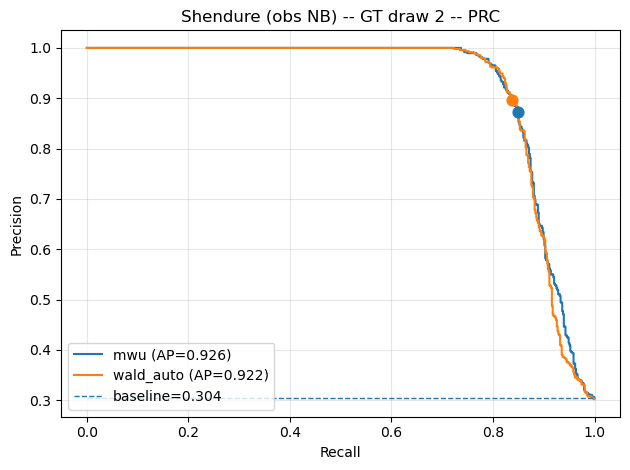

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 587 / 2060 (28.4951%)
Called positive: 600 / 2049 (29.2826%)


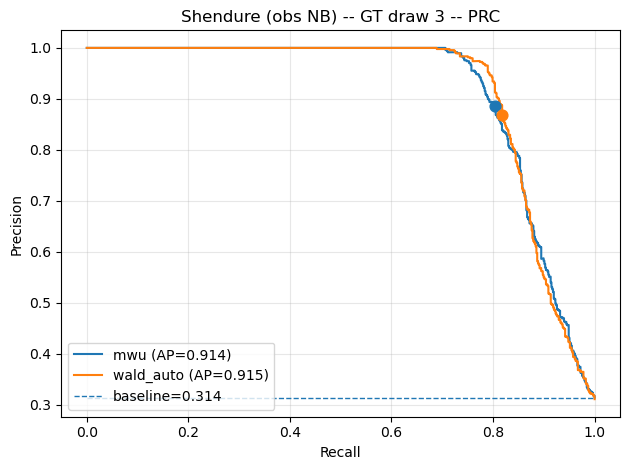

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 584 / 2060 (28.3495%)
Called positive: 582 / 2047 (28.4319%)


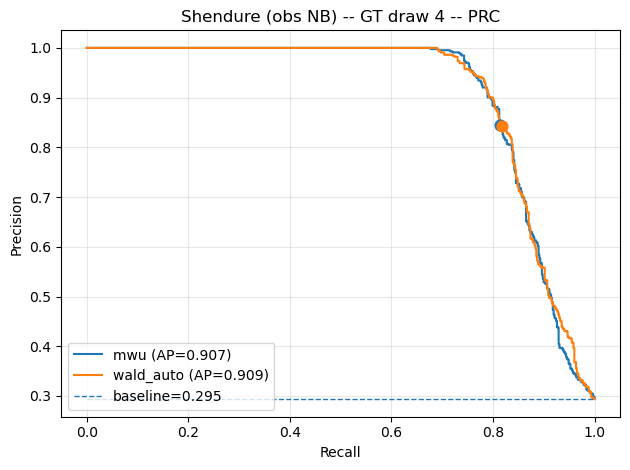

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.



Cohen (obsingle NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 109 / 460 (23.6957%)
Called positive: 167 / 452 (36.9469%)


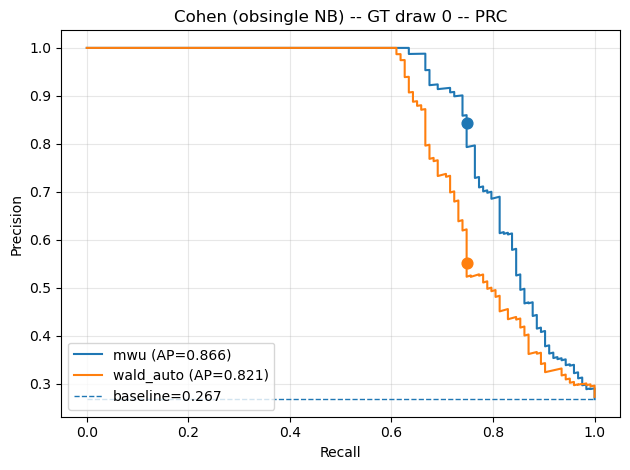

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


Called positive: 107 / 460 (23.2609%)
Called positive: 220 / 460 (47.8261%)


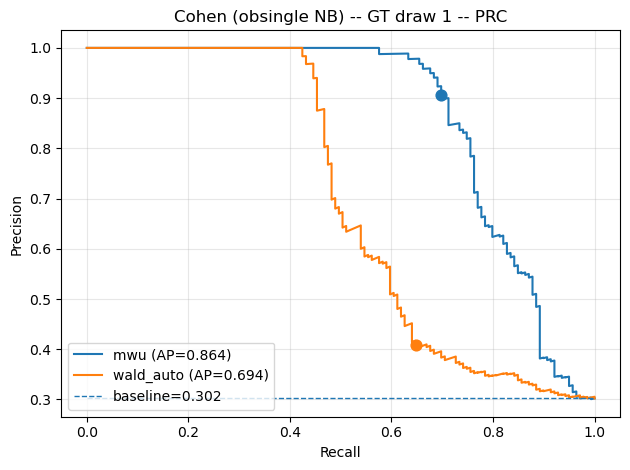

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


Called positive: 115 / 459 (25.0545%)
Called positive: 123 / 454 (27.0925%)


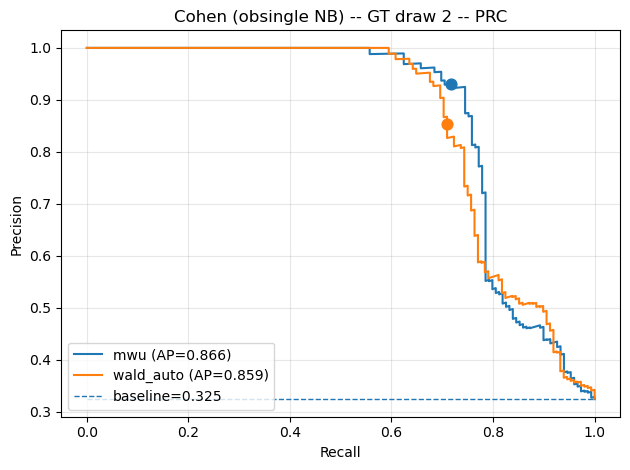

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)


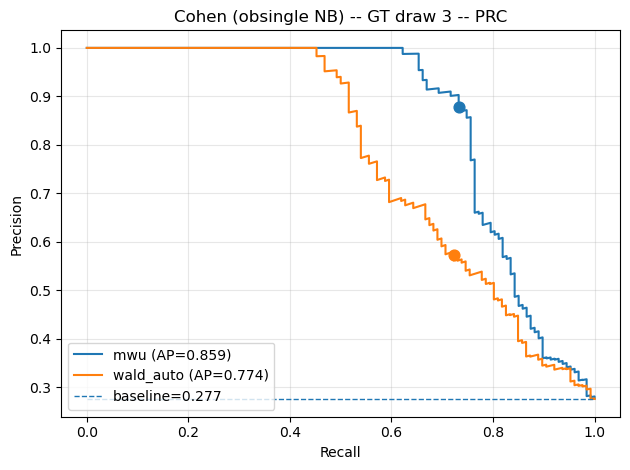

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 108 / 459 (23.5294%)
Called positive: 275 / 457 (60.1751%)


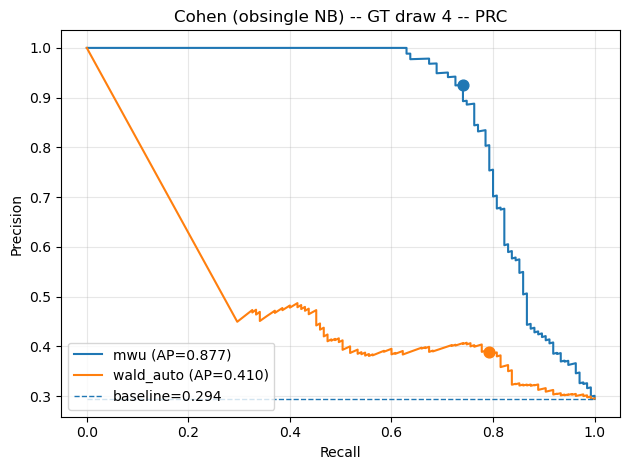


Seelig (CM NB) -- Median-replicate PRC curves


scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1202 or 44.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.8% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


...

scMPRAforge: INFO: Dropped 1274 or 47.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 47.4% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1178 or 43.9% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 43.9% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


Called positive: 222 / 2686 (8.2651%)
Called positive: 514 / 1412 (36.4023%)


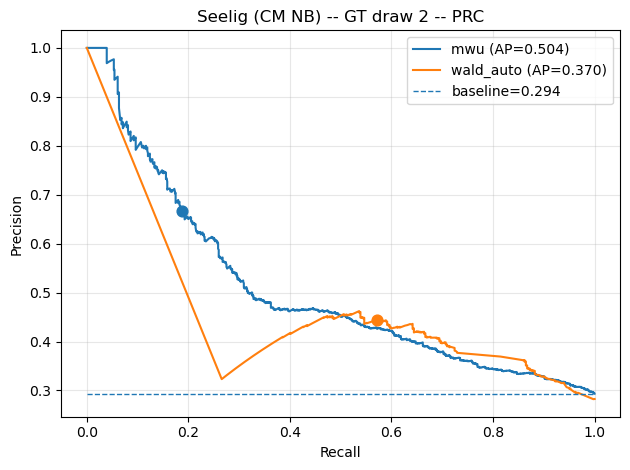

scMPRAforge: INFO: Dropped 1136 or 42.3% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 42.3% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1182 or 44.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.0% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1210 or 45.0% of tests with NA values for test:wald_auto, rep:2.


...

scMPRAforge: INFO: Dropped 1116 or 41.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 41.5% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1224 or 45.6% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 45.6% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


Called positive: 151 / 2686 (5.6217%)
Called positive: 546 / 1504 (36.3032%)


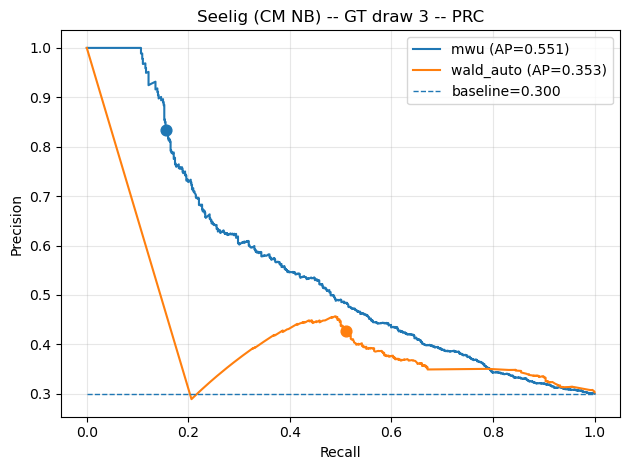

scMPRAforge: INFO: Dropped 1170 or 43.6% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 43.6% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1254 or 46.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 46.7% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 2686 or 100.0% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 100.0% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


  GT 4: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


In [5]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Median-replicate PRC curves")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        try:
            sim.median_performance_curve(
                HYPOTHESIS_SET, "PRC", include_alpha=True
            )
            plt.title(f"{label} -- GT draw {gt_idx} -- PRC")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  GT {gt_idx}: {e}")

## Median-replicate ROC curves

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.



Shendure (obs NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 565 / 2060 (27.4272%)
Called positive: 542 / 2044 (26.5166%)


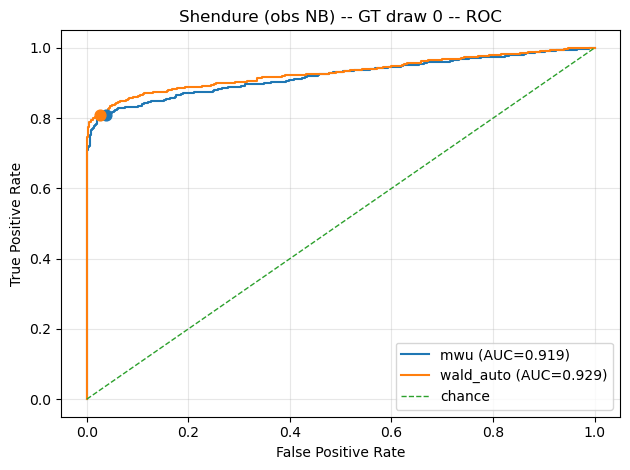

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 613 / 2060 (29.7573%)
Called positive: 568 / 2045 (27.7751%)


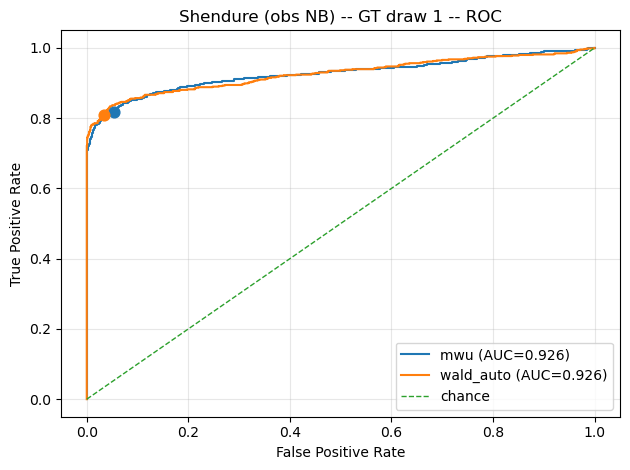

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


Called positive: 609 / 2060 (29.5631%)
Called positive: 562 / 2048 (27.4414%)


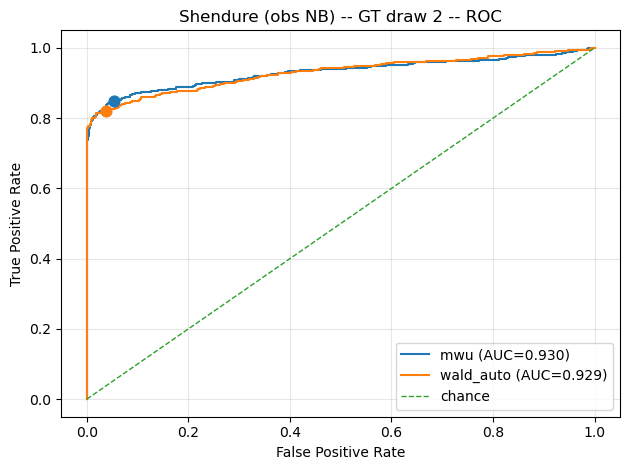

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 622 / 2060 (30.1942%)
Called positive: 595 / 2045 (29.0954%)


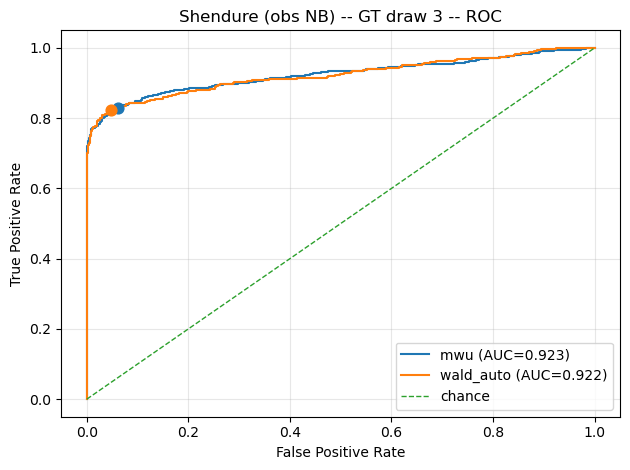

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


Called positive: 584 / 2060 (28.3495%)
Called positive: 582 / 2047 (28.4319%)


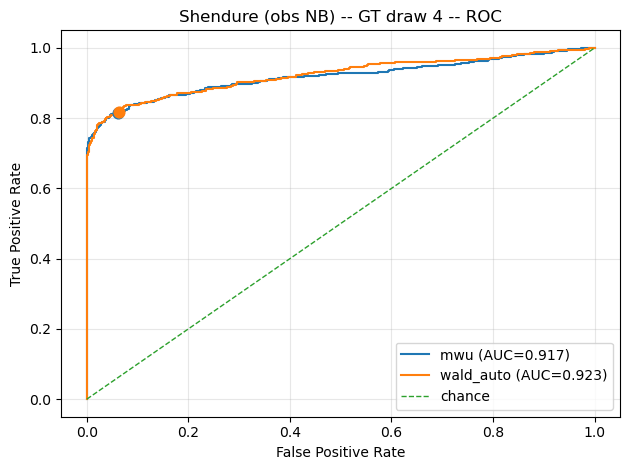

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.



Cohen (obsingle NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 109 / 460 (23.6957%)
Called positive: 167 / 452 (36.9469%)


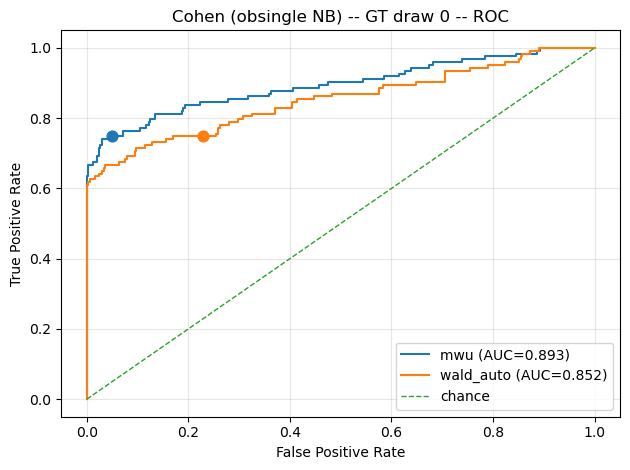

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


Called positive: 107 / 460 (23.2609%)
Called positive: 220 / 460 (47.8261%)


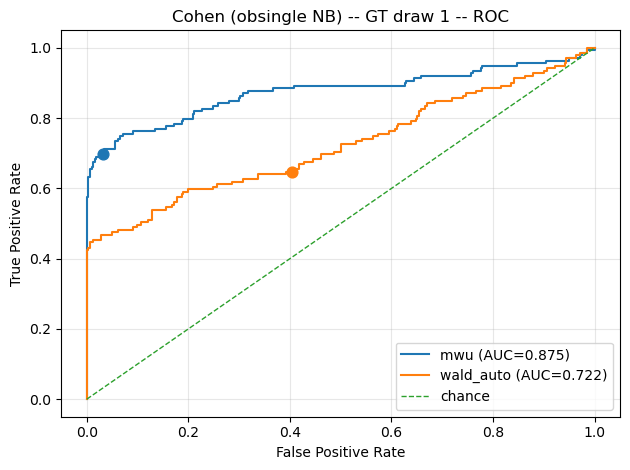

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


Called positive: 115 / 459 (25.0545%)
Called positive: 123 / 454 (27.0925%)


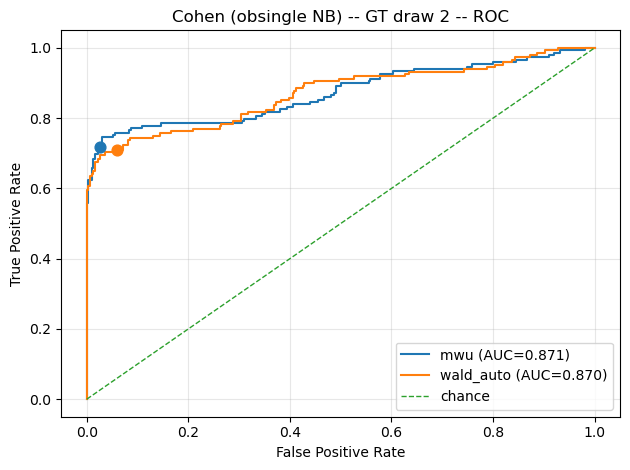

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


Called positive: 106 / 459 (23.0937%)
Called positive: 159 / 457 (34.7921%)


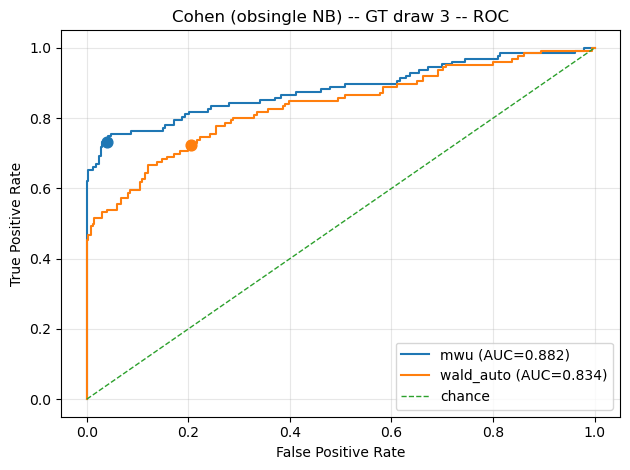

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


Called positive: 108 / 459 (23.5294%)
Called positive: 357 / 459 (77.7778%)


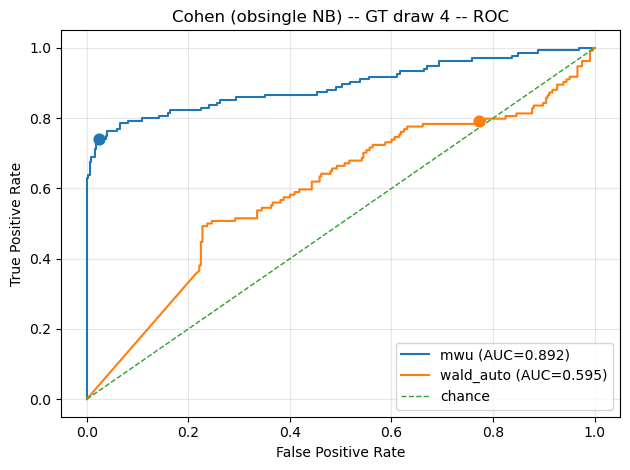


Seelig (CM NB) -- Median-replicate ROC curves


scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1202 or 44.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.8% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


...

scMPRAforge: INFO: Dropped 1274 or 47.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 47.4% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1178 or 43.9% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 43.9% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


Called positive: 140 / 2686 (5.2122%)
Called positive: 214 / 1508 (14.1910%)


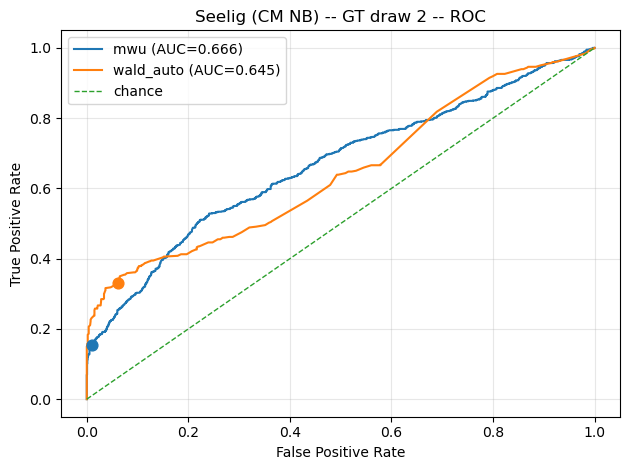

scMPRAforge: INFO: Dropped 1136 or 42.3% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 42.3% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1182 or 44.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.0% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1210 or 45.0% of tests with NA values for test:wald_auto, rep:2.


...

scMPRAforge: INFO: Dropped 1116 or 41.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 41.5% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1224 or 45.6% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 45.6% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


Called positive: 150 / 2686 (5.5845%)
Called positive: 546 / 1504 (36.3032%)


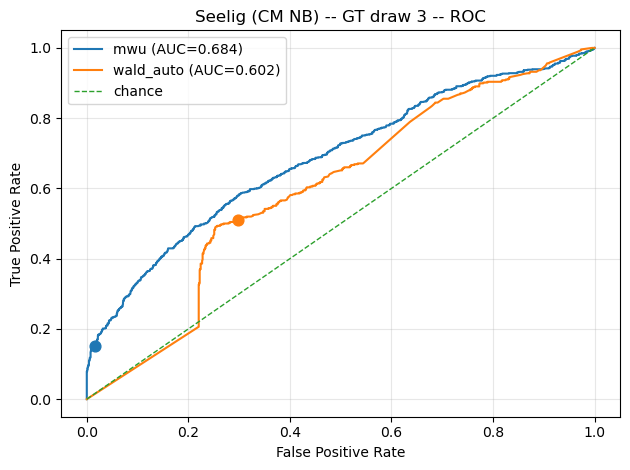

scMPRAforge: INFO: Dropped 1170 or 43.6% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 43.6% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1254 or 46.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 46.7% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 2686 or 100.0% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 100.0% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


  GT 4: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


In [6]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Median-replicate ROC curves")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        try:
            sim.median_performance_curve(
                HYPOTHESIS_SET, "ROC", include_alpha=True
            )
            plt.title(f"{label} -- GT draw {gt_idx} -- ROC")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"  GT {gt_idx}: {e}")

## Performance barcharts (AUROC and AUPRC)

One barchart per GT draw showing test comparison.

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.



Shendure (obs NB) -- Performance barcharts


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


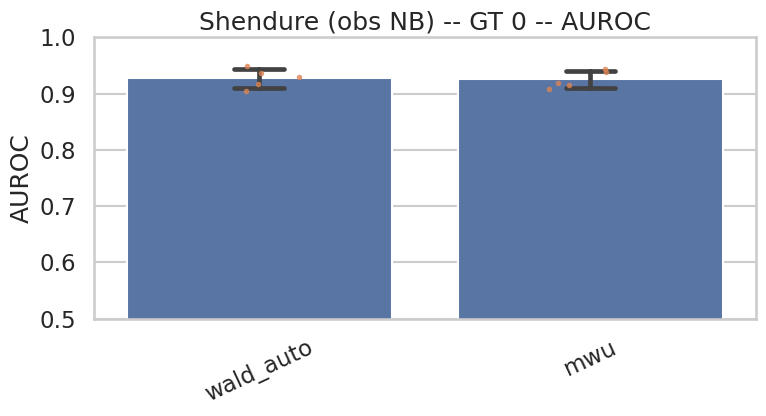

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


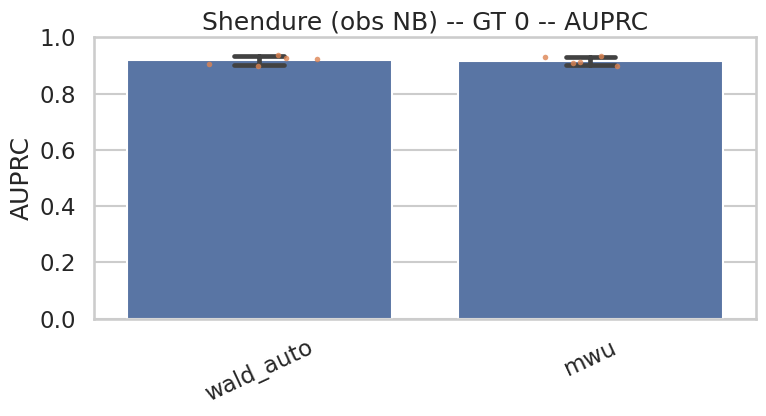

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


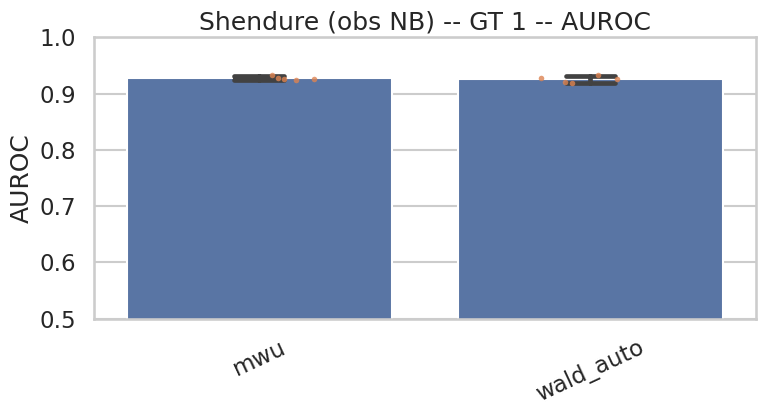

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:4.


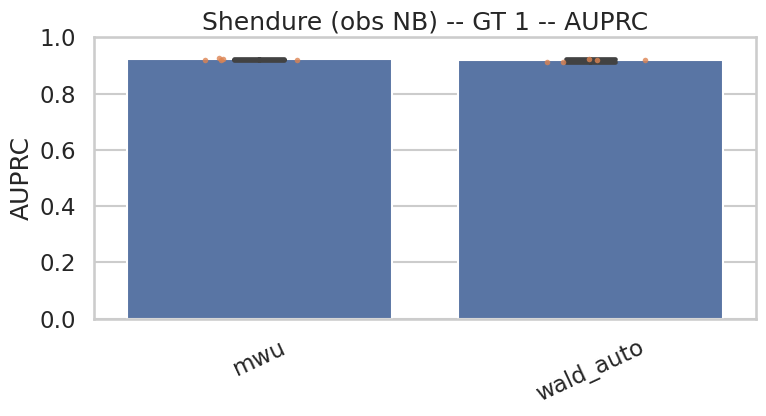

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


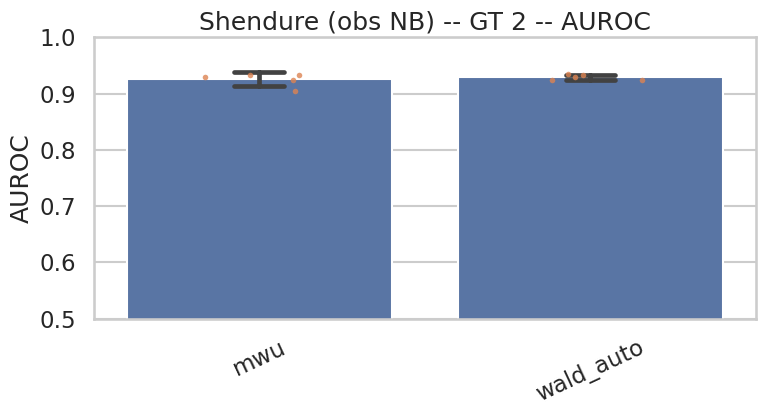

scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 12 or 0.6% of tests with NA values for test:wald_auto, rep:4.


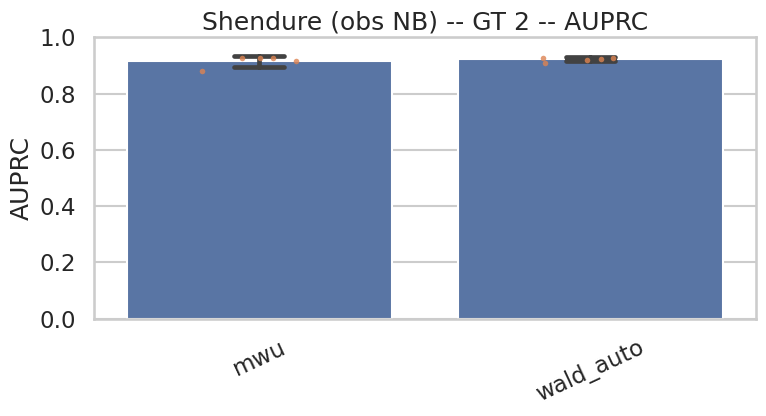

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


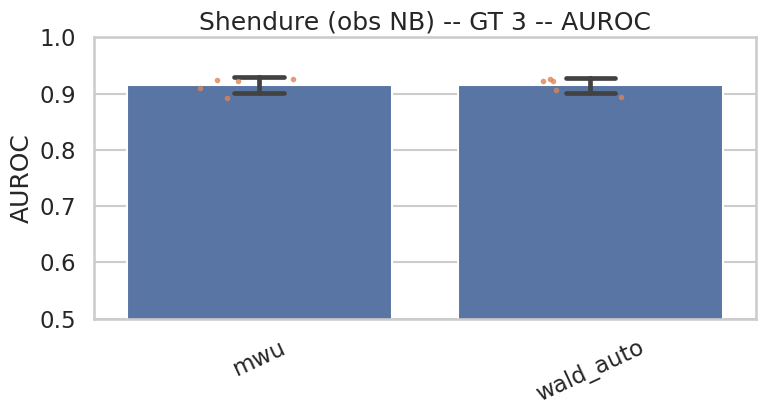

scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 14 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 15 or 0.7% of tests with NA values for test:wald_auto, rep:4.


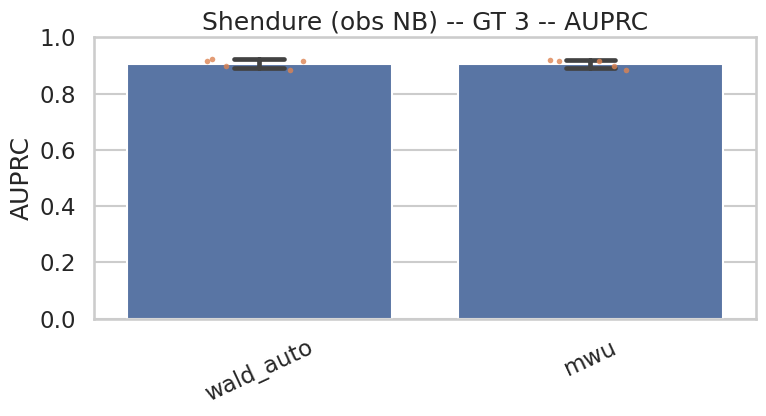

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


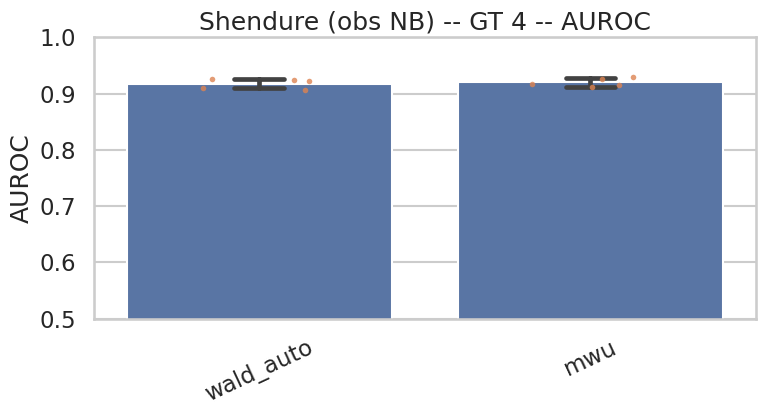

scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 13 or 0.6% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 11 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 6 or 0.3% of tests with NA values for test:wald_auto, rep:4.


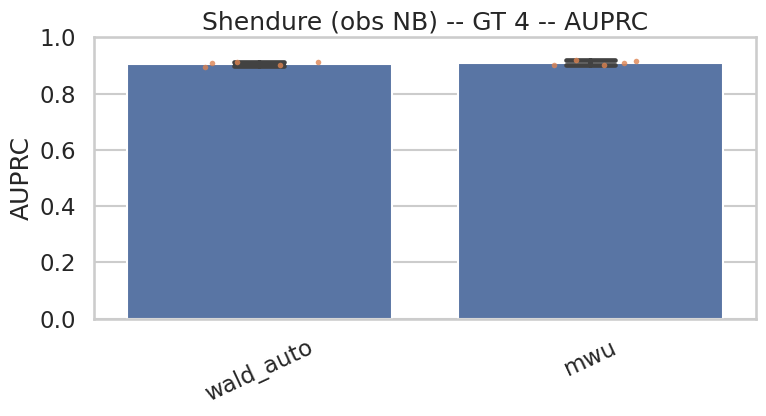

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.



Cohen (obsingle NB) -- Performance barcharts


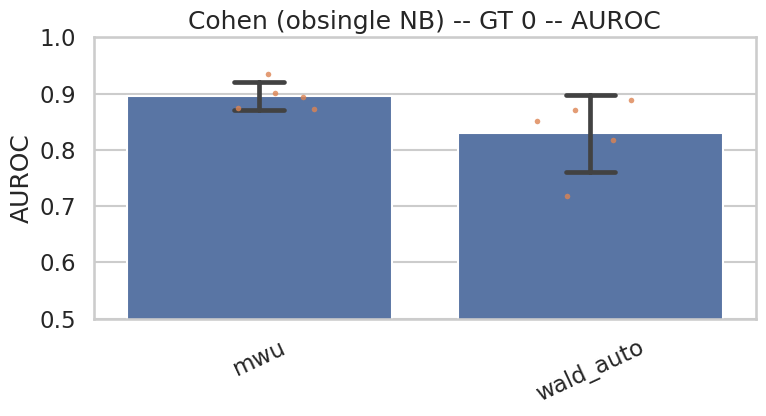

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:2.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 8 or 1.7% of tests with NA values for test:wald_auto, rep:4.


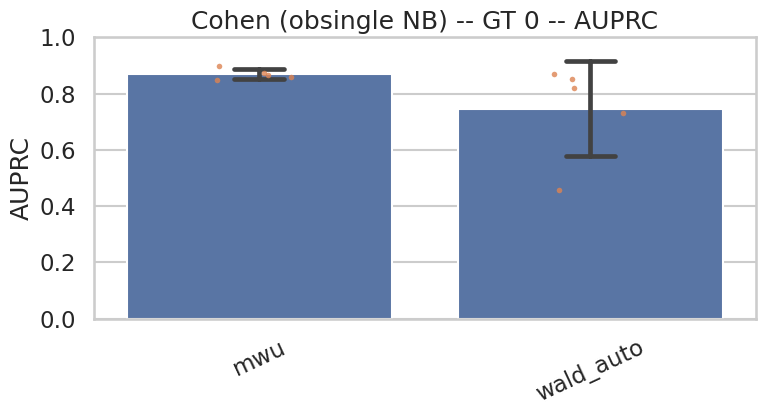

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


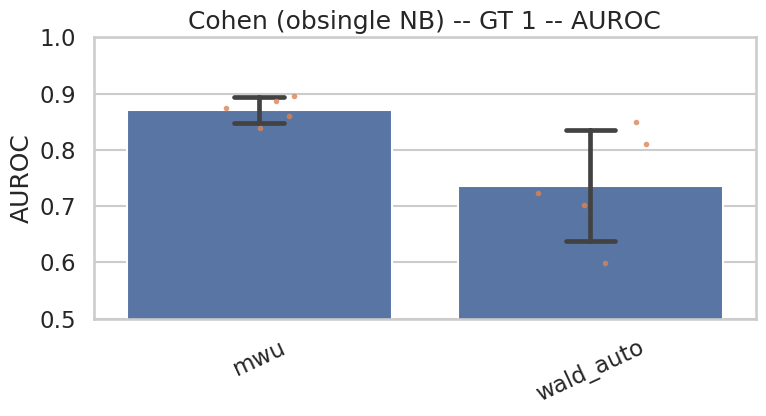

scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 6 or 1.3% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 7 or 1.5% of tests with NA values for test:wald_auto, rep:4.


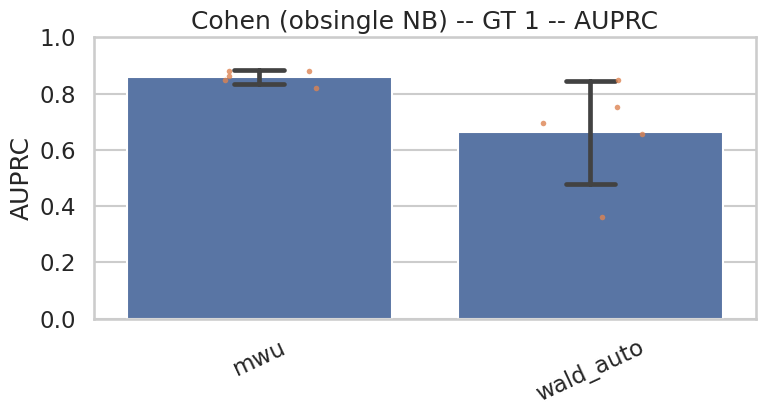

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


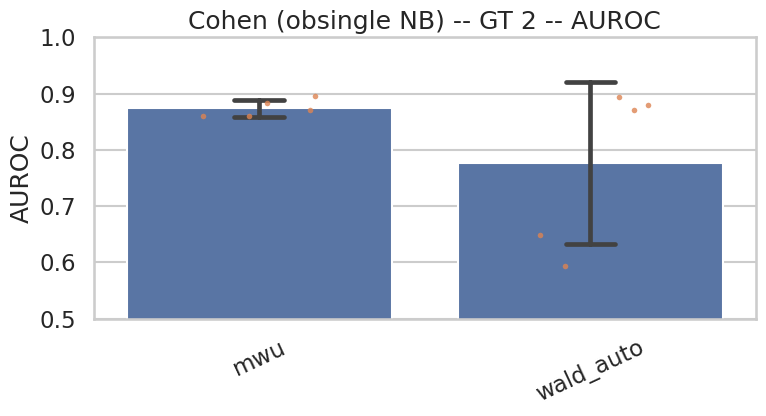

scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 5 or 1.1% of tests with NA values for test:wald_auto, rep:4.


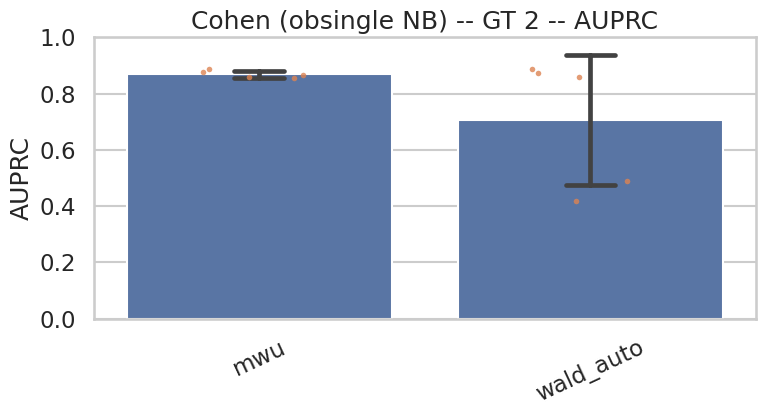

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


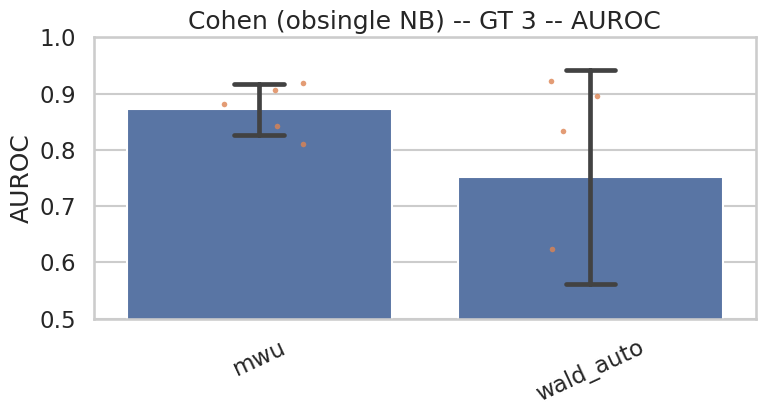

scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 4 or 0.9% of tests with NA values for test:wald_auto, rep:4.


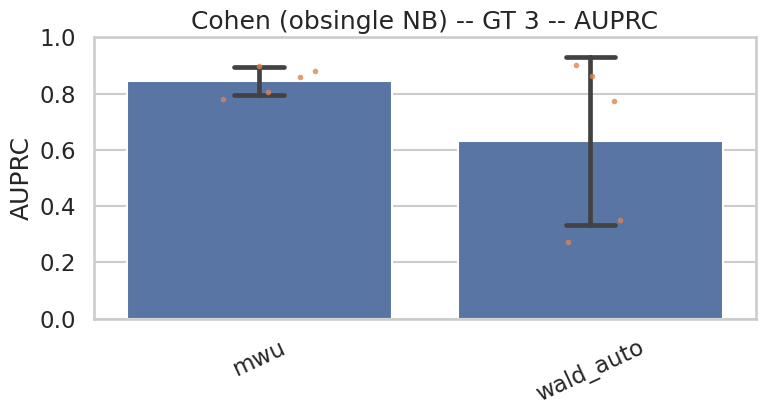

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


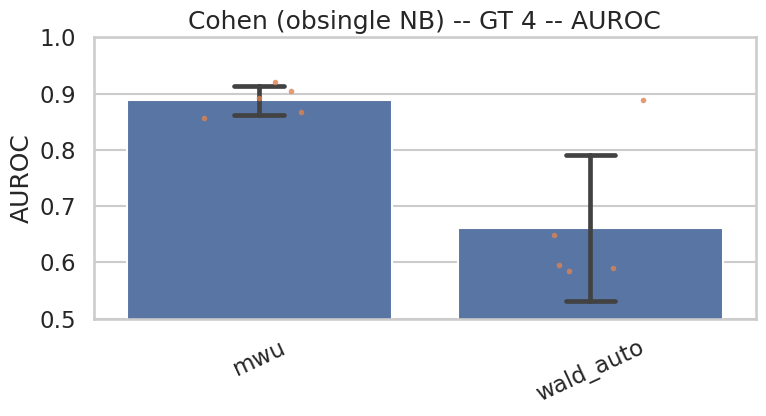

scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:mwu, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:mwu, rep:4.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 9 or 2.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: INFO: Dropped 1 or 0.2% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 2 or 0.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: INFO: Dropped 3 or 0.7% of tests with NA values for test:wald_auto, rep:4.


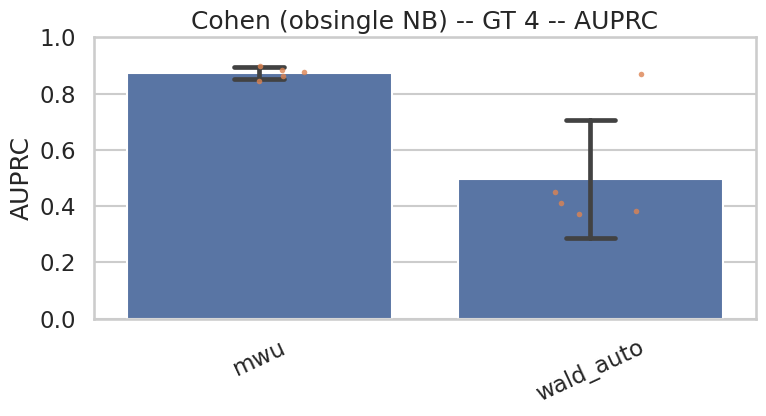

scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1202 or 44.8% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.8% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.



Seelig (CM NB) -- Performance barcharts


...

scMPRAforge: WARNING: NA rate 43.7% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1274 or 47.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 47.4% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1178 or 43.9% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 43.9% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


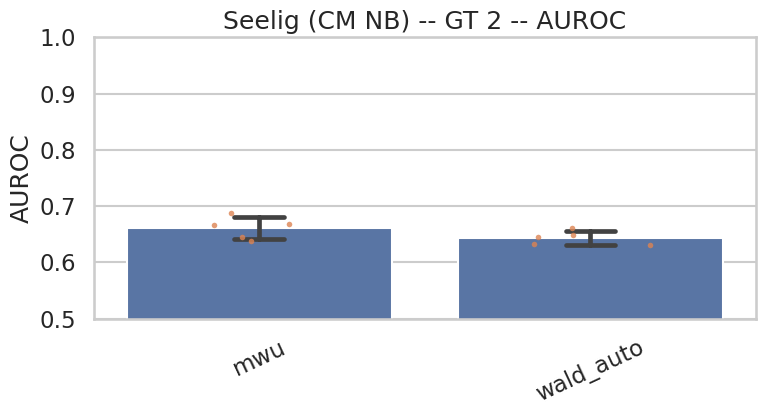

scMPRAforge: INFO: Dropped 1228 or 45.7% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 45.7% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1236 or 46.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 46.0% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1174 or 43.7% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 43.7% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1274 or 47.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 47.4% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1178 or 43.9% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 43.9% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


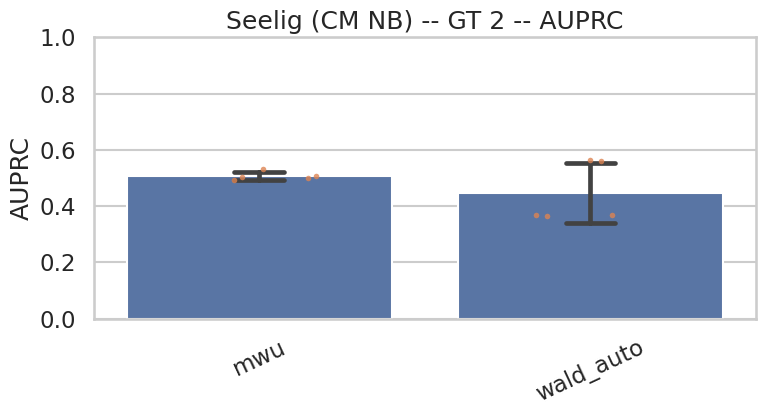

scMPRAforge: INFO: Dropped 1136 or 42.3% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 42.3% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1182 or 44.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.0% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1210 or 45.0% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 45.0% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1116 or 41.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 41.5% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1224 or 45.6% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 45.6% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


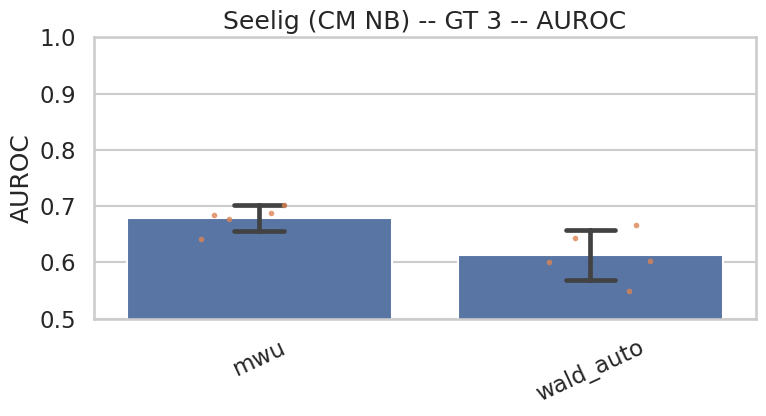

scMPRAforge: INFO: Dropped 1136 or 42.3% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 42.3% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1182 or 44.0% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 44.0% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1210 or 45.0% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 45.0% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1116 or 41.5% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 41.5% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1224 or 45.6% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 45.6% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


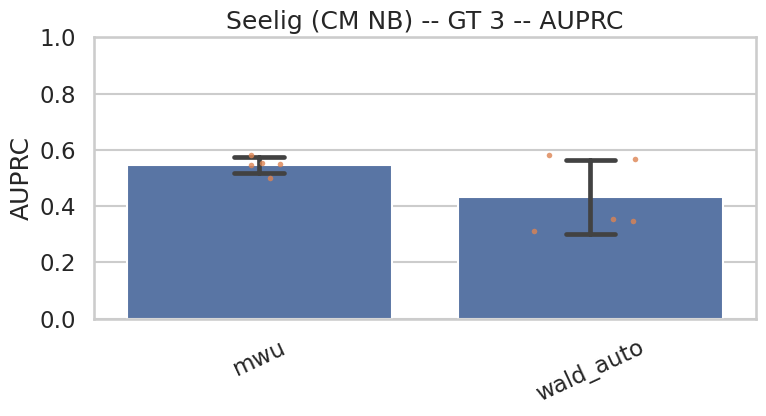

scMPRAforge: INFO: Dropped 1170 or 43.6% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: WARNING: NA rate 43.6% exceeds 5% threshold for test:wald_auto, rep:0. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1254 or 46.7% of tests with NA values for test:wald_auto, rep:1.


scMPRAforge: WARNING: NA rate 46.7% exceeds 5% threshold for test:wald_auto, rep:1. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:2.


...

scMPRAforge: INFO: Dropped 1194 or 44.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: WARNING: NA rate 44.5% exceeds 5% threshold for test:wald_auto, rep:2. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 2686 or 100.0% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 100.0% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


  GT 4 auprc: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.


In [7]:
for label, gt_sims in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} -- Performance barcharts")
    print(f"{'='*60}")
    for gt_idx, sim in enumerate(gt_sims):
        for metric in ["auroc", "auprc"]:
            try:
                sim.performance_barchart(HYPOTHESIS_SET, metric)
                plt.title(f"{label} -- GT {gt_idx} -- {metric.upper()}")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"  GT {gt_idx} {metric}: {e}")

## Cross-dataset comparison boxplots

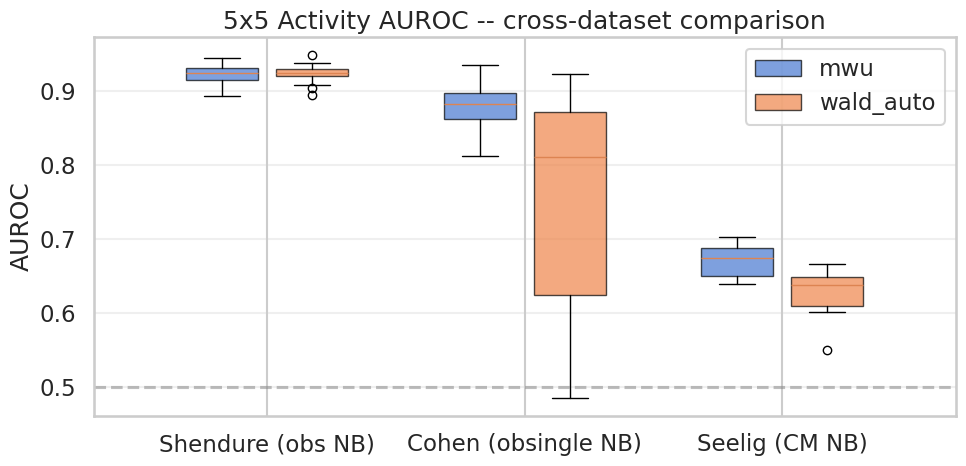

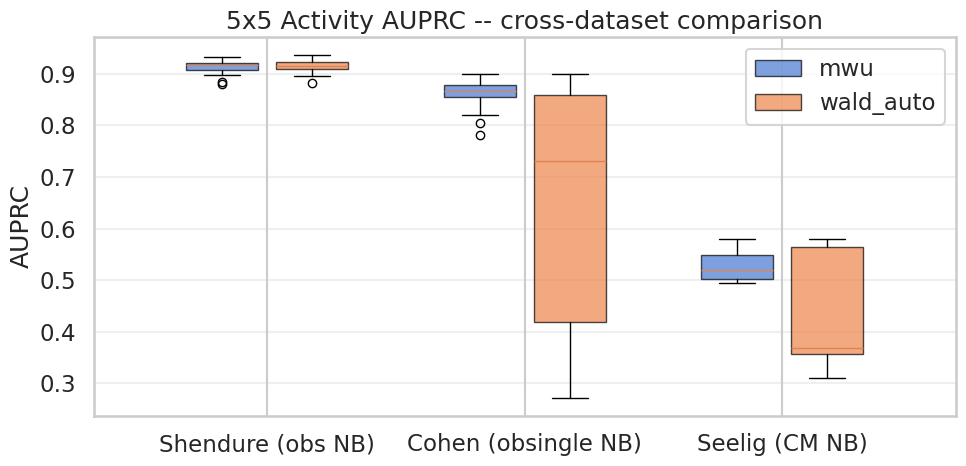

In [8]:
if all_summaries:
    combined = pd.concat(
        [df.assign(dataset=label) for label, df in all_summaries.items()],
        ignore_index=True
    )

    for metric in ["auroc", "auprc"]:
        fig, ax = plt.subplots(figsize=(10, 5))
        datasets = list(all_summaries.keys())
        tests = sorted(combined["test"].unique())
        n_tests = len(tests)
        width = 0.35
        x = range(len(datasets))

        for i, test in enumerate(tests):
            offsets = [xi + (i - n_tests/2 + 0.5) * width for xi in x]
            vals = []
            for ds in datasets:
                sub = combined[(combined["dataset"] == ds) & (combined["test"] == test)]
                vals.append(sub[metric].values)
            bp = ax.boxplot(vals, positions=offsets, widths=width * 0.8,
                           patch_artist=True,
                           boxprops=dict(facecolor=["#4878d0", "#ee854a"][i % 2], alpha=0.7))
            # Label only the first box of each test
            bp["boxes"][0].set_label(test)

        ax.set_xticks(list(x))
        ax.set_xticklabels(datasets)
        ax.set_ylabel(metric.upper())
        ax.set_title(f"5x5 Activity {metric.upper()} -- cross-dataset comparison")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="y")
        if metric == "auroc":
            ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
        fig.tight_layout()
        plt.show()

## Paper figure: median GT draw, median replicate

For each dataset, select the GT draw whose mean AUROC (across tests and reps)
is closest to the overall median. Then show that draw's median-replicate
PRC and ROC curves. This is the "representative" result for the paper;
the per-draw breakdown above documents robustness.

scMPRAforge: INFO: Dropped 16 or 0.8% of tests with NA values for test:wald_auto, rep:0.


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:1.


Shendure (obs NB): median GT draw = 0 (mean AUROC=0.926, overall median=0.926, range=0.915-0.927)
Cohen (obsingle NB): median GT draw = 3 (mean AUROC=0.812, overall median=0.812, range=0.775-0.862)
Seelig (CM NB): median GT draw = 2 (mean AUROC=0.652, overall median=0.649, range=0.646-0.652)


scMPRAforge: INFO: Dropped 10 or 0.5% of tests with NA values for test:wald_auto, rep:2.


scMPRAforge: INFO: Dropped 18 or 0.9% of tests with NA values for test:wald_auto, rep:3.


...

scMPRAforge: INFO: Dropped 1274 or 47.4% of tests with NA values for test:wald_auto, rep:3.


scMPRAforge: WARNING: NA rate 47.4% exceeds 5% threshold for test:wald_auto, rep:3. Proceeding but results may be biased.


scMPRAforge: INFO: Dropped 1178 or 43.9% of tests with NA values for test:wald_auto, rep:4.


scMPRAforge: WARNING: NA rate 43.9% exceeds 5% threshold for test:wald_auto, rep:4. Proceeding but results may be biased.


Called positive: 140 / 2686 (5.2122%)
Called positive: 214 / 1508 (14.1910%)


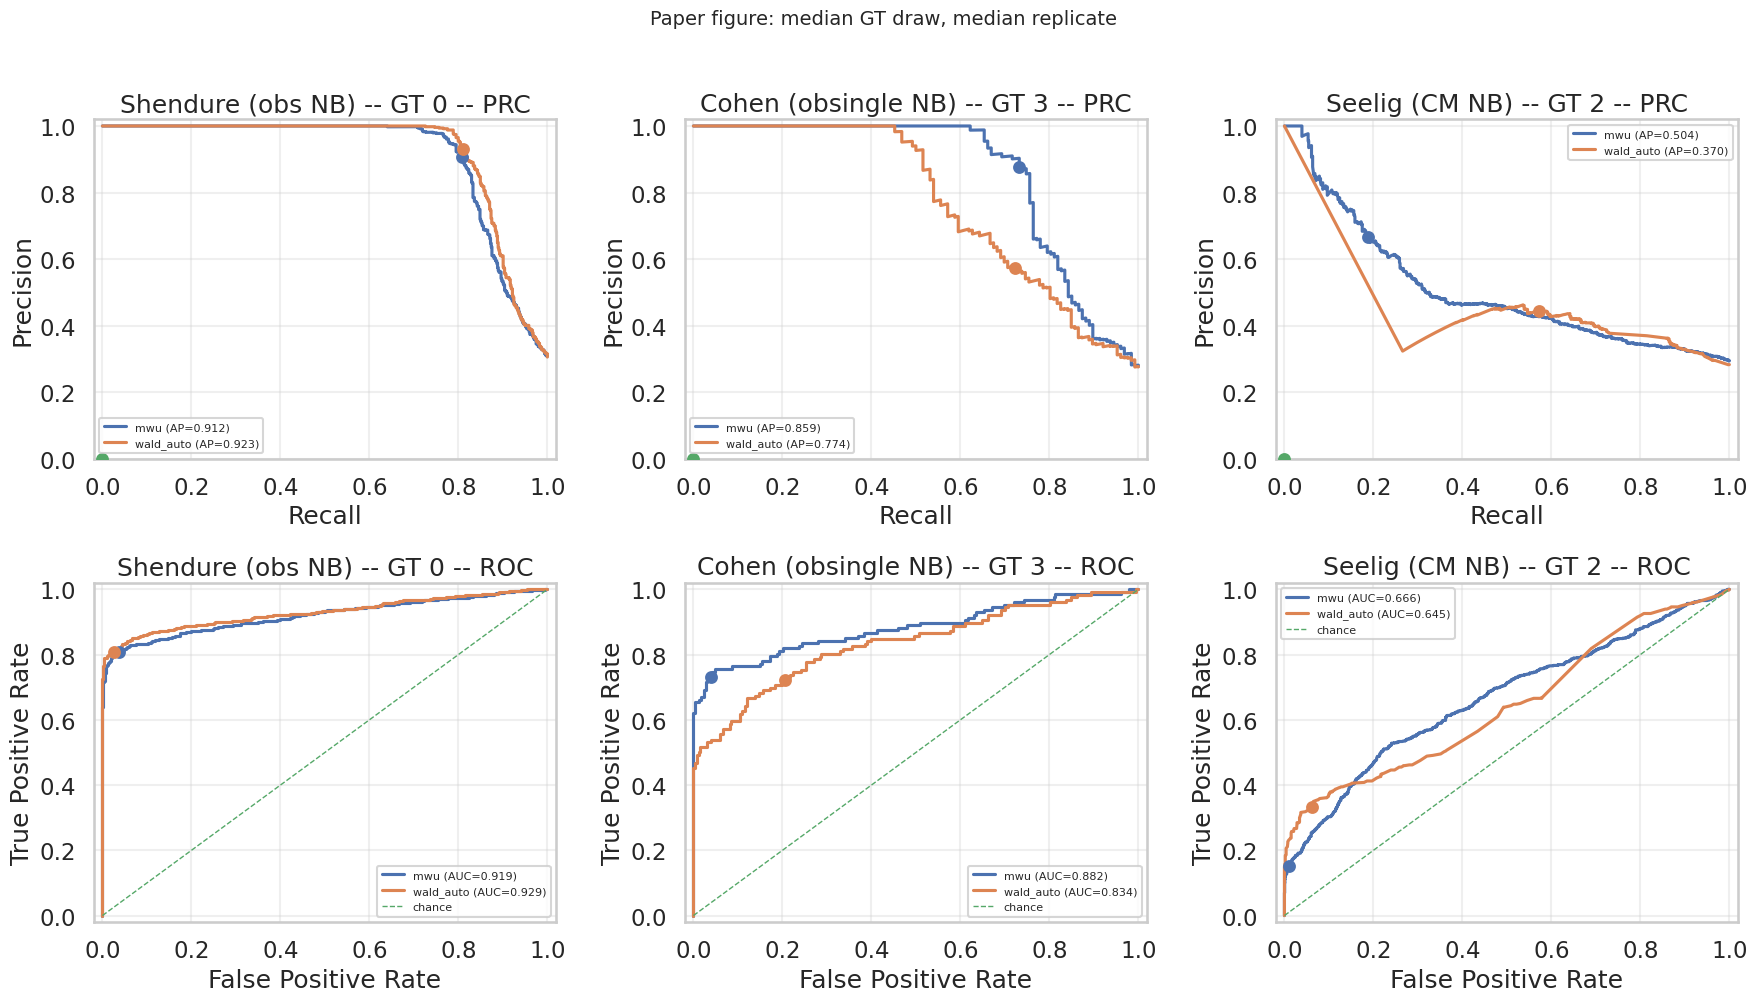

In [9]:
# Pick median GT draw per dataset
median_gt = {}
for label, df in all_summaries.items():
    gt_means = df.groupby("gt_draw")["auroc"].mean()
    overall_median = gt_means.median()
    best_gt = (gt_means - overall_median).abs().idxmin()
    median_gt[label] = int(best_gt)
    print(f"{label}: median GT draw = {best_gt} "
          f"(mean AUROC={gt_means[best_gt]:.3f}, "
          f"overall median={overall_median:.3f}, "
          f"range={gt_means.min():.3f}-{gt_means.max():.3f})")

# Show PRC and ROC for the median GT draw
fig, axes = plt.subplots(2, len(sims), figsize=(6 * len(sims), 10),
                         squeeze=False)

for col, (label, gt_sims) in enumerate(sims.items()):
    gt_idx = median_gt.get(label, 0)
    sim = gt_sims[gt_idx]
    for row, kind in enumerate(["PRC", "ROC"]):
        plt.sca(axes[row, col])
        try:
            sim.median_performance_curve(
                HYPOTHESIS_SET, kind, include_alpha=True
            )
            # median_performance_curve creates its own figure; steal its axes
            src_fig = plt.gcf()
            if src_fig is not fig:
                # Copy lines from the standalone figure to our grid
                src_ax = src_fig.axes[0]
                ax = axes[row, col]
                for line in src_ax.get_lines():
                    ax.plot(line.get_xdata(), line.get_ydata(),
                            label=line.get_label(),
                            color=line.get_color(),
                            linestyle=line.get_linestyle(),
                            linewidth=line.get_linewidth())
                for coll in src_ax.collections:
                    # scatter points (alpha threshold markers)
                    offsets = coll.get_offsets()
                    if len(offsets) > 0:
                        ax.scatter(offsets[:, 0], offsets[:, 1], s=60, zorder=5)
                ax.set_xlabel(src_ax.get_xlabel())
                ax.set_ylabel(src_ax.get_ylabel())
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
                if kind == "ROC":
                    ax.set_xlim(-0.02, 1.02)
                    ax.set_ylim(-0.02, 1.02)
                else:
                    ax.set_xlim(-0.02, 1.02)
                    ax.set_ylim(0, 1.02)
                plt.close(src_fig)
        except Exception as e:
            axes[row, col].text(0.5, 0.5, str(e), ha="center", va="center",
                                transform=axes[row, col].transAxes, fontsize=9)
        axes[row, col].set_title(f"{label} -- GT {gt_idx} -- {kind}")

fig.suptitle("Paper figure: median GT draw, median replicate", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()